In [1]:
import sys
import introns
import importlib
import warnings
import pickle

import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

from Bio import SeqIO
from Bio.SeqUtils import gc_fraction
from termcolor import colored
from sklearn.utils import class_weight
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, precision_recall_fscore_support, multilabel_confusion_matrix

importlib.reload(introns)

<module 'introns' from '/home/semik/projekty/ml_attempts/temporarycleaningbranch_noncanonical_introns/introns.py'>

In [2]:
#file = "./fastas_and_gff/introns_for_classifier_training.fasta"
file = "./fastas_and_gff/introns_for_3-class_classifier_training.fasta"
#file = "./fastas_and_gff/introns_for_4-class_classifier_training.fasta"

GCs = [gc_fraction(record.seq) for record in SeqIO.parse(file, "fasta")]
lengths = [len(record.seq) for record in SeqIO.parse(file, "fasta")]
mean_GC = sum(GCs)/len(GCs)
mean_length = sum(lengths)/len(lengths)
print(mean_GC, mean_length)

0.5338085117059286 802.0421924290221


In [3]:
no_K, no_NK, no_I, no_random = 0, 0, 0, 0
for record in SeqIO.parse(file, "fasta"):
    i_type = record.description.split()[-1]
    if i_type == "intron_K": no_K += 1
    elif i_type == "intron_NK": no_NK +=1
    elif i_type == "intron_I": no_I +=1
    else: no_random +=1
print(no_K, no_NK, no_I, no_random)

368 422 11 1735


In [4]:
teal_color = "#599191"

In [5]:
classifiers_acc_prec_rec_f = {}

## Trenowanie
4 klasy: konw, niekonw, inne pozycje, losowe sekwencje

In [6]:
### checking if introns are not their own variants

seqs = [i for i in SeqIO.parse("./fastas_and_gff/introns_for_4-class_classifier_training.fasta", 'fasta')]
for id1 in range(len(seqs)-1):
    s1 = seqs[id1]
    for id2 in range(id1+1, len(seqs)):
        s2 = seqs[id2]
        if s1.seq==s2.seq:
            print(s1.description)
            print(s2.description)
            print('\n')

In [7]:
introns_seqs, introns_classes, introns_characteristics = [], [], []
f = open("./fastas_and_gff/introns_for_4-class_classifier_training.fasta", 'r')
for l in f.readlines():
    if l.startswith(">"):
        t = l.split()[-1]
        intron_type = 0 if t=="intron_K" else (1 if t=="intron_NK" else (2 if t=="intron_other" else 3))
    else:
        prev_exon_seq, intron_seq, next_exon_seq = l[:5], l[5:-5], l[-5:]
        its_characteristics = introns.compute_intron_characteristics(l)
        introns_seqs.append((prev_exon_seq, intron_seq, next_exon_seq))
        introns_classes.append(intron_type)
        introns_characteristics.append(its_characteristics)
print(len(introns_seqs), len(introns_classes), len(introns_characteristics))

X_train, X_test, y_train, y_test = train_test_split(introns_characteristics, introns_classes, test_size=0.3, random_state=420)
introns_classes = np.array(introns_classes).reshape(-1,1)
classes_weights_4head = class_weight.compute_sample_weight(class_weight='balanced', y=y_train)

2683 2683 2683


In [8]:
# correlation matrix btwn characteristics
pd.DataFrame(introns_characteristics).corr().style.background_gradient(cmap='coolwarm')
#plt.matshow(pd.DataFrame(introns_characteristics).corr())

/home/semik/miniconda3/envs/python310/lib/python3.10/site-packages/pandas/io/formats/style.py:3807: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
/home/semik/miniconda3/envs/python310/lib/python3.10/site-packages/pandas/io/formats/style.py:3808: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,0,1,2,3,4,5,6,7
0,1.000000,-0.032637,nan,0.025867,-0.001080,0.009390,-0.006380,-0.023067
1,-0.032637,1.000000,nan,0.009685,0.002912,0.044288,-0.006155,0.082354
2,nan,nan,nan,nan,nan,nan,nan,nan
3,0.025867,0.009685,nan,1.000000,0.023267,0.021713,0.039523,0.017068
4,-0.001080,0.002912,nan,0.023267,1.000000,0.000996,-0.007578,-0.011659
5,0.009390,0.044288,nan,0.021713,0.000996,1.000000,0.163832,0.169260
6,-0.006380,-0.006155,nan,0.039523,-0.007578,0.163832,1.000000,0.028626
7,-0.023067,0.082354,nan,0.017068,-0.011659,0.169260,0.028626,1.000000


In [9]:
#clf_4head = xgb.XGBClassifier(use_label_encoder=False, eval_metric='aucpr', objective='multi:softmax')
clf_4head = xgb.XGBClassifier(use_label_encoder=False,
                              eval_metric=balanced_accuracy_score,
                              objective='multi:softmax',
                              seed=123)
clf_4head.fit(X_train, y_train, sample_weight=classes_weights_4head);

pred_4head = clf_4head.predict(X_test)

In [10]:
acc = balanced_accuracy_score(y_test,pred_4head)
print("4-class classifier accuracy score:", acc)

precision, recall, fscore, _ = precision_recall_fscore_support(y_test,pred_4head)
print(f'''
Precision:    {precision}
recall:       {recall}
f-score:      {fscore}
''')
classifiers_acc_prec_rec_f['bac 4-class'] = (acc, precision, recall, fscore)
print("confusion matrix:", multilabel_confusion_matrix(y_test,pred_4head))

4-class classifier accuracy score: 0.4189531420972217

Precision:    [0.22147651 0.63333333 0.71527778 0.05405405]
recall:       [0.31730769 0.67375887 0.61067194 0.07407407]
f-score:      [0.26086957 0.65292096 0.65884861 0.0625    ]

confusion matrix: [[[585 116]
  [ 71  33]]

 [[609  55]
  [ 46  95]]

 [[176 123]
  [197 309]]

 [[681  70]
  [ 50   4]]]


In [11]:
### pickle.dump(clf_4head, open('4head_classifier.model', 'wb'))

## Trenowanie
3 klasy: konw, niekonw, inne pozycje

In [12]:
### sprawdzanie ze introny nie sa swoimi wlasnymi wariantami

seqs = [i for i in SeqIO.parse("./fastas_and_gff/introns_for_3-class_classifier_training.fasta", 'fasta')]
for id1 in range(len(seqs)-1):
    s1 = seqs[id1]
    for id2 in range(id1+1, len(seqs)):
        s2 = seqs[id2]
        if s1.seq==s2.seq:
            print(s1.description)
            print(s2.description)
            print('\n')

In [13]:
introns_seqs, introns_classes, introns_characteristics = [], [], []
f = open("./fastas_and_gff/introns_for_3-class_classifier_training.fasta", 'r')
for l in f.readlines():
    if l.startswith(">"):
        t = l.split()[-1]
        intron_type = 0 if t=="intron_K" else (1 if t=="intron_NK" else 2)
    else:
        prev_exon_seq, intron_seq, next_exon_seq = l[:5], l[5:-5], l[-5:]
        its_characteristics = introns.compute_intron_characteristics(l)
        introns_seqs.append((prev_exon_seq, intron_seq, next_exon_seq))
        introns_classes.append(intron_type)
        introns_characteristics.append(its_characteristics)
print(len(introns_seqs), len(introns_classes), len(introns_characteristics))

introns_classes = np.array(introns_classes).reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(introns_characteristics, introns_classes, test_size=0.3, random_state=420)
classes_weights_3head = class_weight.compute_sample_weight(class_weight='balanced', y=y_train)

2536 2536 2536


In [14]:
# correlation matrix btwn characteristics
pd.DataFrame(introns_characteristics).corr().style.background_gradient(cmap='coolwarm')

,0,1,2,3,4,5,6,7
0,1.000000,-0.030748,-0.019489,-0.035362,0.002056,0.002590,0.008190,-0.047346
1,-0.030748,1.000000,-0.019877,-0.011047,-0.033942,-0.015045,0.011831,0.016785
2,-0.019489,-0.019877,1.000000,0.019721,-0.020369,0.038747,-0.006132,-0.014972
3,-0.035362,-0.011047,0.019721,1.000000,-0.000968,0.003712,-0.007490,0.013513
4,0.002056,-0.033942,-0.020369,-0.000968,1.000000,-0.004000,-0.036729,0.045776
5,0.002590,-0.015045,0.038747,0.003712,-0.004000,1.000000,0.144870,0.158058
6,0.008190,0.011831,-0.006132,-0.007490,-0.036729,0.144870,1.000000,0.010032
7,-0.047346,0.016785,-0.014972,0.013513,0.045776,0.158058,0.010032,1.000000


In [15]:
# clf_3head = MultiOutputClassifier(xgb.XGBClassifier(use_label_encoder=False,
#                                                     eval_metric='aucpr',
#                                                     objective='multi:softmax'))
clf_3head = MultiOutputClassifier(xgb.XGBClassifier(use_label_encoder=False,
                                                    eval_metric=balanced_accuracy_score,
                                                    objective='multi:softmax',
                                                    seed=123))
clf_3head.fit(X_train, y_train, sample_weight=classes_weights_3head);

pred_3head = clf_3head.predict(X_test)

In [16]:
acc = balanced_accuracy_score(y_test,pred_3head)
print("3-class classifier accuracy score:", acc)

precision, recall, fscore, _ = precision_recall_fscore_support(y_test,pred_3head)
#print("Precision:\t", precision)
#print("recall:\t\t", recall)
#print("f-score:\t", fscore)
print(f'''
Precision:    {precision}
recall:       {recall}
f-score:      {fscore}
''')
classifiers_acc_prec_rec_f['multi 3-class'] = (acc, precision, recall, fscore)

print(multilabel_confusion_matrix(y_test,pred_3head))

3-class classifier accuracy score: 0.6374066374066374

Precision:    [0.3880597  0.63235294 0.80651731]
recall:       [0.41269841 0.73504274 0.76447876]
f-score:      [0.4        0.6798419  0.78493558]

[[[553  82]
  [ 74  52]]

 [[594  50]
  [ 31  86]]

 [[148  95]
  [122 396]]]


In [17]:
### pickle.dump(clf_3head, open('3head_classifier.model', 'wb'))

## Trenowanie
4 klasy: konw, niekonw, intermediate, losowe sekwencje

In [18]:
introns_seqs, introns_classes, introns_characteristics = [], [], []
#f = open("introns_for_classifier_training_w_random.fasta", 'r')
f = open("./fastas_and_gff/introns_for_3-class_classifier_training.fasta", 'r')
for l in f.readlines():
    if l.startswith(">"):
        t = l.split()[-1]
        intron_type = 0 if t=="intron_K" else (1 if t=="intron_NK" else (2 if t=="intron_I" else 3))
    else:
        #prev_exon_seq, intron_seq, next_exon_seq = l[:5], l[5:-5], l[-5:]
        #its_characteristics = introns.compute_intron_characteristics(prev_exon_seq, intron_seq, next_exon_seq)
        its_characteristics = introns.compute_intron_characteristics(l)
        introns_seqs.append((prev_exon_seq, intron_seq, next_exon_seq))
        introns_classes.append(intron_type)
        introns_characteristics.append(its_characteristics)
print(len(introns_seqs), len(introns_classes), len(introns_characteristics))

introns_classes = np.array(introns_classes).reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(introns_characteristics, introns_classes, test_size=0.3, random_state=420)


clf_4head = MultiOutputClassifier(xgb.XGBClassifier(eval_metric='aucpr'))
clf_4head.fit(X_train, y_train);

pred_4head = clf_4head.predict(X_test)


acc = accuracy_score(y_test,pred_4head)
print("4-class classifier accuracy score:", acc)

precision, recall, fscore, _ = precision_recall_fscore_support(y_test,pred_4head)
print(f'''
Precision:    {precision}
recall:       {recall}
f-score:      {fscore}
''')
classifiers_acc_prec_rec_f['multi 4-class'] = (acc, precision, recall, fscore)

print(multilabel_confusion_matrix(y_test,pred_4head))

2536 2536 2536
4-class classifier accuracy score: 0.7411300919842313

Precision:    [0.46666667 0.71028037 0.         0.76683087]
recall:       [0.16666667 0.64957265 0.         0.90503876]
f-score:      [0.24561404 0.67857143 0.         0.83022222]

[[[611  24]
  [105  21]]

 [[613  31]
  [ 41  76]]

 [[759   0]
  [  2   0]]

 [[103 142]
  [ 49 467]]]


## Trenowanie - multiklasy

In [19]:
introns_seqs, introns_classes, introns_characteristics = [], [], []
f = open("./fastas_and_gff/introns_for_3-class_classifier_training.fasta", 'r')
for l in f.readlines():
    if l.startswith(">"):
        t = l.split()[-1]
        intron_type = 0 if t=="intron_K" else (1 if t=="intron_NK" else 2)
    else:
        prev_exon_seq, intron_seq, next_exon_seq = l[:5], l[5:-5], l[-5:]
        its_characteristics = introns.compute_intron_characteristics(prev_exon_seq+intron_seq+next_exon_seq)
        introns_seqs.append((prev_exon_seq, intron_seq, next_exon_seq))
        introns_classes.append(intron_type)
        introns_characteristics.append(its_characteristics)
print(len(introns_seqs), len(introns_classes), len(introns_characteristics))

introns_classes_multi = []
for i in introns_classes:
    is_k = True if i==0 else False
    is_nk = True if i==1 else False
    introns_classes_multi.append([is_k, is_nk])
    
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(introns_characteristics, introns_classes_multi, test_size=0.3, random_state=420)
classes_weights_multi = class_weight.compute_sample_weight(class_weight='balanced', y=y_train)

2536 2536 2536


In [20]:
#clf_multi = MultiOutputClassifier(xgb.XGBClassifier(eval_metric='aucpr'))
clf_multi = MultiOutputClassifier(xgb.XGBClassifier(eval_metric=balanced_accuracy_score, seed=123))
clf_multi.fit(X_train_multi, y_train_multi, sample_weight=classes_weights_multi);

In [21]:
pred_multi = clf_multi.predict(X_test_multi)


#print("Multiclass classifier accuracy score:", balanced_accuracy_score(y_test_multi,pred_multi))

precision, recall, fscore, _ = precision_recall_fscore_support(y_test_multi,pred_multi)
print(f'''
Precision:    {precision}
recall:       {recall}
f-score:      {fscore}
''')
print(multilabel_confusion_matrix(y_test_multi,pred_multi))

classifiers_acc_prec_rec_f['double multilabel'] = (0, precision, recall, fscore)


Precision:    [0.35338346 0.64285714]
recall:       [0.37301587 0.69230769]
f-score:      [0.36293436 0.66666667]

[[[549  86]
  [ 79  47]]

 [[599  45]
  [ 36  81]]]


In [22]:
### pickle.dump(clf_multi, open('multi_classifier.model', 'wb'))

Comparison of classifiers

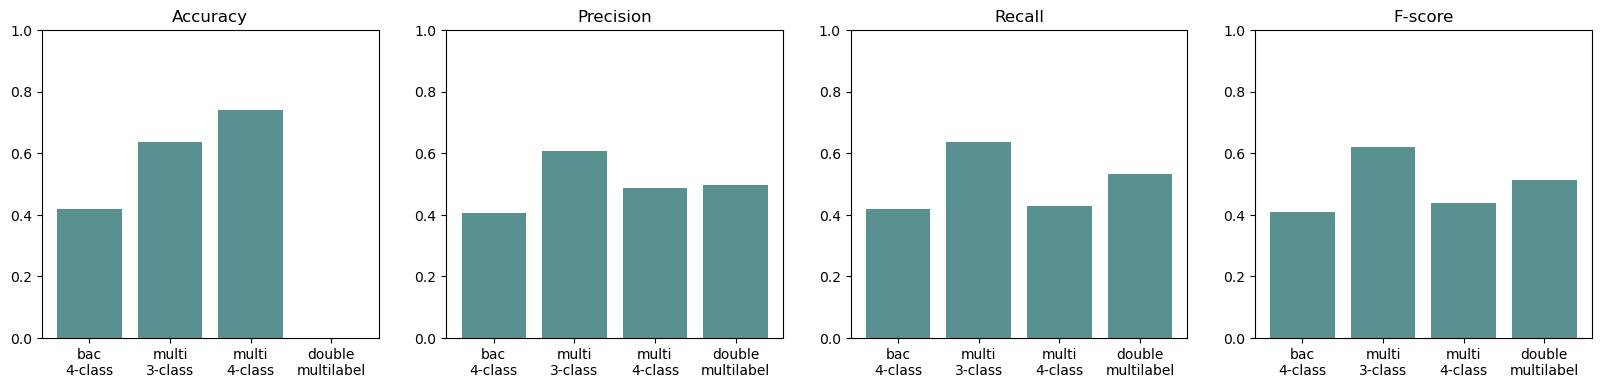

In [23]:
classifiers = classifiers_acc_prec_rec_f.keys()
classifiers = [c.replace(" ", "\n") for c in classifiers]
accuracies = [x[0] for x in classifiers_acc_prec_rec_f.values()]
precisions = [x[1] for x in classifiers_acc_prec_rec_f.values()]
recalls = [x[2] for x in classifiers_acc_prec_rec_f.values()]
fscores = [x[3] for x in classifiers_acc_prec_rec_f.values()]

fig, ax = plt.subplots(1,4,figsize=(20,4))
ax = ax.flatten()

#for classifier, a in zip(classifiers,accuracies):
ax[0].bar(classifiers, accuracies, color=teal_color)
ax[0].set_title('Accuracy')
ax[0].set_ylim((0,1))

ax[1].bar(classifiers, [np.mean(l) for l in precisions], color=teal_color)
ax[1].set_title('Precision')
ax[1].set_ylim((0,1))

ax[2].bar(classifiers, [np.mean(l) for l in recalls], color=teal_color)
ax[2].set_title('Recall')
ax[2].set_ylim((0,1))

ax[3].bar(classifiers, [np.mean(l) for l in fscores], color=teal_color)
ax[3].set_title('F-score')
ax[3].set_ylim((0,1))

plt.savefig('3_classifiers_scores.png')
plt.show()

## Stats w/ classifiers

In [28]:
clf_3head = pickle.load(open('./Models/3head_classifier.model', 'rb'))
clf_4head = pickle.load(open('./Models/4head_classifier.model', 'rb'))
clf_multi = pickle.load(open('./Models/multi_classifier.model', 'rb'))